In [1]:
%run ../../../setup_workspace.py # ../ means level up 
from scipy.interpolate import interp1d

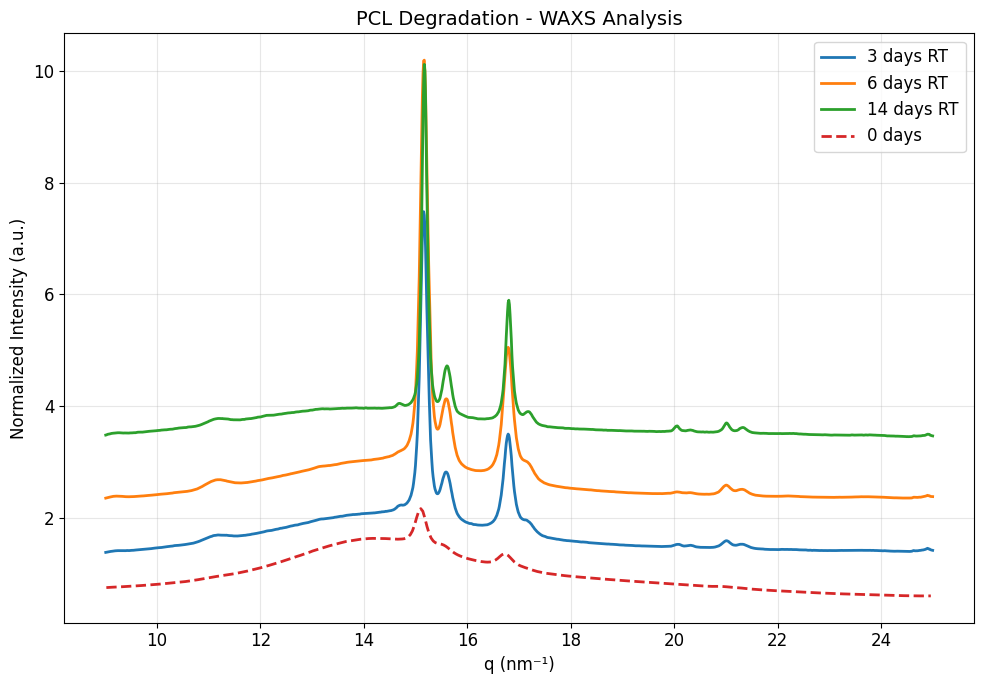

          q   I_0days         q   I_3days   I_6days  I_14days
0  9.021859  0.752482  9.010175  1.382101  2.353237  3.481470
1  9.062114  0.755196  9.022370  1.383928  2.355792  3.484119
2  9.102368  0.757250  9.034565  1.386575  2.358547  3.490244
3  9.142623  0.759369  9.046761  1.389058  2.361224  3.494665
4  9.182878  0.760756  9.058956  1.390837  2.364227  3.496671


In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Параметры
left_lim = 9
right_lim = 25

plt.figure(figsize=(10, 7))

# Список для хранения DataFrame
dfs = []

# Образец 3 days
path = r"E:\PEG_PCL\degradation\Degradation_PCL_20perc_3days_RT"
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 1
plt.plot(X, Y_norm, label='3 days RT', linewidth=2)
df_3 = pd.DataFrame({'q': X, 'I_3days': Y_norm})
dfs.append(df_3)

# Образец 6 days
path = r"E:\PEG_PCL\degradation\Degradation_PCL_20perc_6days_RT"
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 2
plt.plot(X, Y_norm, label='6 days RT', linewidth=2)
df_6 = pd.DataFrame({'q': X, 'I_6days': Y_norm})
dfs.append(df_6)

# Образец 14 days
path = r"E:\PEG_PCL\degradation\Degradation_PCL_20perc_14days_RT"
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 3
plt.plot(X, Y_norm, label='14 days RT', linewidth=2)
df_14 = pd.DataFrame({'q': X, 'I_14days': Y_norm})
dfs.append(df_14)

# Образец 0 days
path = r"E:\PEG_PCL\Akmal_plots\PEG_waxs_00444_00_av.dat"
df = pd.read_table(path, skiprows=1, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 400
plt.plot(X, Y_norm, label='0 days', linewidth=2, linestyle='--')
df_0 = pd.DataFrame({'q': X, 'I_0days': Y_norm})

# Объединяем все в один DataFrame
df_degradation = pd.concat(dfs, axis=1)
df_degradation = df_degradation.loc[:,~df_degradation.columns.duplicated()]  # убираем дубликат q
df_degradation = pd.concat([df_0, df_degradation], axis=1)

# Сохраняем
df_degradation.to_csv(r'E:\PEG_PCL\Akmal_plots\degradation_all.txt', sep='\t', index=False)

# Оформление
plt.xlabel('q (nm⁻¹)', fontsize=12)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=12)
plt.title('PCL Degradation - WAXS Analysis', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(df_degradation.head())

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_17176\1493683772.py:10: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')
C:\Users\LabPCA\AppData\Local\Temp\ipykernel_17176\1493683772.py:22: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')
C:\Users\LabPCA\AppData\Local\Temp\ipykernel_17176\1493683772.py:34: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpret

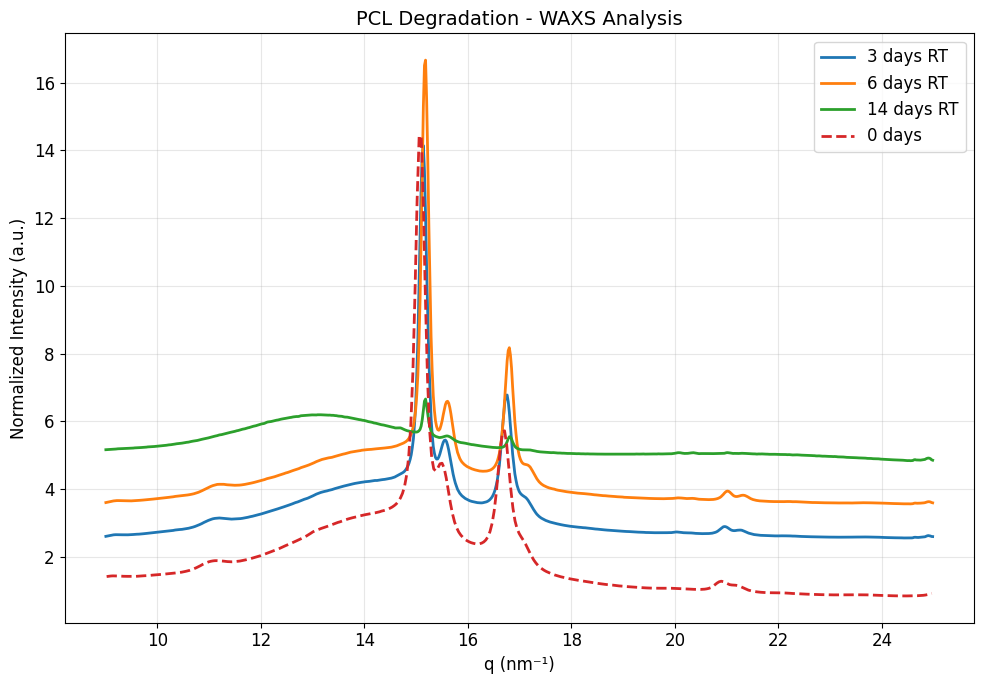

          q   I_0days         q   I_3days   I_6days  I_14days
0  9.021859  1.413961  9.007044  2.601307  3.598943  5.160240
1  9.062114  1.423699  9.028343  2.608066  3.606346  5.162310
2  9.102368  1.430130  9.049642  2.616191  3.614449  5.164620
3  9.142623  1.433814  9.070941  2.623436  3.620673  5.167771
4  9.182878  1.433448  9.092240  2.630270  3.628270  5.170263


In [71]:
# Параметры
left_lim = 9
right_lim = 25

plt.figure(figsize=(10, 7))

dfs = []

path = r"E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_M3_3daysRT_WAXS_0000.dat"
df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')
q, I = np.array(df['q']), np.array(df['I'])
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 2
plt.plot(X, Y_norm, label='3 days RT', linewidth=2)
df_3 = pd.DataFrame({'q': X, 'I_3days': Y_norm})
dfs.append(df_3)

# Образец 6 days
path = r"E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_M3_6daysRT_WAXS_0000.dat"
df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')
q, I = np.array(df['q']), np.array(df['I'])
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 3
plt.plot(X, Y_norm, label='6 days RT', linewidth=2)
df_6 = pd.DataFrame({'q': X, 'I_6days': Y_norm})
dfs.append(df_6)

# Образец 14 days
path = r"E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_M3_14daysRT_WAXS_0000.dat"
df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')
q, I = np.array(df['q']), np.array(df['I'])
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 4
plt.plot(X, Y_norm, label='14 days RT', linewidth=2)
df_14 = pd.DataFrame({'q': X, 'I_14days': Y_norm})
dfs.append(df_14)

# Образец 0 days
path = r"E:\PEG_PCL\Akmal_plots\PEG_waxs_00090_00_c.dat"
df = pd.read_table(path, skiprows=1, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 800
plt.plot(X, Y_norm, label='0 days', linewidth=2, linestyle='--')
df_0 = pd.DataFrame({'q': X, 'I_0days': Y_norm})

# Объединяем все в один DataFrame
df_degradation = pd.concat(dfs, axis=1)
df_degradation = df_degradation.loc[:,~df_degradation.columns.duplicated()]  # убираем дубликат q
df_degradation = pd.concat([df_0, df_degradation], axis=1)

# Сохраняем
df_degradation.to_csv(r'E:\PEG_PCL\Akmal_plots\degradation_all_Nsc11.txt', sep='\t', index=False)

# Оформление
plt.xlabel('q (nm⁻¹)', fontsize=12)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=12)
plt.title('PCL Degradation - WAXS Analysis', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(df_degradation.head())

E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_10_3days_RT_WAXS_0000.dat
E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_10_6d_RT_WAXS_0000.dat
E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_10_14days_RT_WAXS_0000.dat


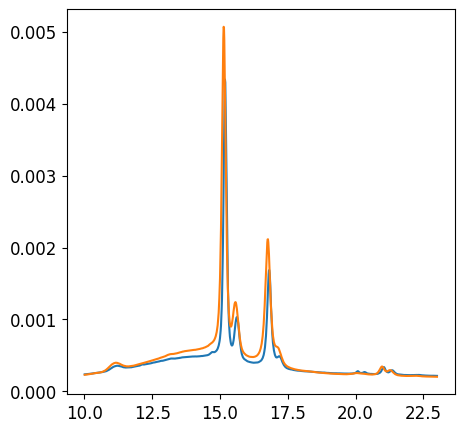

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Параметры
left_lim = 9
right_lim = 25

plt.figure(figsize=(10, 7))

# Список для хранения DataFrame
dfs = []

# Образец 3 days
path = r"E:\PEG_PCL\degradation\Degradation_PCL_20perc_3days_RT"
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 1
plt.plot(X, Y_norm, label='3 days RT', linewidth=2)
df_3 = pd.DataFrame({'q': X, 'I_3days': Y_norm})
dfs.append(df_3)

# Образец 6 days
path = r"E:\PEG_PCL\degradation\Degradation_PCL_20perc_6days_RT"
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 2
plt.plot(X, Y_norm, label='6 days RT', linewidth=2)
df_6 = pd.DataFrame({'q': X, 'I_6days': Y_norm})
dfs.append(df_6)

# Образец 14 days
path = r"E:\PEG_PCL\degradation\Degradation_PCL_20perc_14days_RT"
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 1000 + 3
plt.plot(X, Y_norm, label='14 days RT', linewidth=2)
df_14 = pd.DataFrame({'q': X, 'I_14days': Y_norm})
dfs.append(df_14)

# Образец 0 days
path = r"E:\PEG_PCL\Akmal_plots\PEG_waxs_00444_00_av.dat"
df = pd.read_table(path, skiprows=1, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
mask = (q > left_lim) & (q < right_lim)
X = q[mask]
Y = I[mask]
Y_norm = Y / np.trapezoid(Y) * 400
plt.plot(X, Y_norm, label='0 days', linewidth=2, linestyle='--')
df_0 = pd.DataFrame({'q': X, 'I_0days': Y_norm})

# Объединяем все в один DataFrame
df_degradation = pd.concat(dfs, axis=1)
df_degradation = df_degradation.loc[:,~df_degradation.columns.duplicated()]  # убираем дубликат q
df_degradation = pd.concat([df_0, df_degradation], axis=1)

# Сохраняем
df_degradation.to_csv(r'E:\PEG_PCL\Akmal_plots\degradation_all.txt', sep='\t', index=False)

# Оформление
plt.xlabel('q (nm⁻¹)', fontsize=12)
plt.ylabel('Normalized Intensity (a.u.)', fontsize=12)
plt.title('PCL Degradation - WAXS Analysis', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(df_degradation.head())